In [ ]:
%pip install scikit-learn numpy pandas matplotlib seaborn umap-learn

In [51]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import HDBSCAN
from sklearn.datasets import make_blobs

## Data Cleaning

In [30]:
import pandas as pd

data_path = "data/star-galaxy-quasar.csv"
df = pd.read_csv(data_path, sep=",", skiprows=1)

print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

if "class" in df.columns:
    print("\nClass distribution:")
    print(df["class"].value_counts())

display(df.head())

Shape: (10000, 10)

Data types:
objid         int64
ra          float64
dec         float64
u           float64
g           float64
r           float64
i           float64
z           float64
class           str
redshift    float64
dtype: object

Missing values:
objid       0
ra          0
dec         0
u           0
g           0
r           0
i           0
z           0
class       0
redshift    0
dtype: int64

Duplicate rows: 0

Class distribution:
class
GALAXY    8449
STAR       865
QSO        686
Name: count, dtype: int64


,objid,ra,dec,u,g,r,i,z,class,redshift
0,1237654669735231608,149.142428,-0.372420,19.76743,17.87560,16.90248,16.45606,16.12213,GALAXY,0.091934
1,1237651801233686770,149.117936,0.183976,18.20582,16.46298,15.49704,14.95910,14.60985,GALAXY,0.065808
2,1237651800696881217,149.156198,-0.315231,19.78793,18.33921,17.48833,17.07277,16.74467,GALAXY,0.085327
3,1237654670272102476,149.128104,0.083621,20.33225,18.35458,17.40644,16.95075,16.59546,GALAXY,0.088111
4,1237651801233752148,149.153997,0.172473,19.67747,18.19364,17.51096,17.09774,16.89891,GALAXY,0.079039


In [31]:
# Keep true labels aside only for evaluation
real_y = None
if "class" in df.columns:
    real_y = df["class"].copy()

## Drop identifier/ label columns
df_dropped = df.drop(columns=["objid", "class"]).copy()
df_dropped.head()

,ra,dec,u,g,r,i,z,redshift
0,149.142428,-0.372420,19.76743,17.87560,16.90248,16.45606,16.12213,0.091934
1,149.117936,0.183976,18.20582,16.46298,15.49704,14.95910,14.60985,0.065808
2,149.156198,-0.315231,19.78793,18.33921,17.48833,17.07277,16.74467,0.085327
3,149.128104,0.083621,20.33225,18.35458,17.40644,16.95075,16.59546,0.088111
4,149.153997,0.172473,19.67747,18.19364,17.51096,17.09774,16.89891,0.079039


In [32]:
# Standardization

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Store column names before scaling
column_names = df_dropped.columns

df_standard = scaler.fit_transform(df_dropped)
df_standard = pd.DataFrame(df_standard, columns=column_names)
display(df_standard.head())
df_standard.size

,ra,dec,u,g,r,i,z,redshift
0,-1.433938,-0.515361,0.034267,0.034965,0.033196,0.035976,0.037200,-0.293454
1,-1.436229,0.265014,0.029765,0.031051,0.029143,0.031979,0.033299,-0.372305
2,-1.432650,-0.435150,0.034326,0.036249,0.034885,0.037623,0.038806,-0.313394
3,-1.435278,0.124261,0.035895,0.036292,0.034649,0.037297,0.038421,-0.304992
4,-1.432856,0.248881,0.034007,0.035846,0.034950,0.037690,0.039204,-0.332371


80000

## HDBScan

In [ ]:
# PCA

from sklearn.decomposition import PCA

# apply PCA 
pca = PCA(n_components=6)
pca_data = pca.fit_transform(df_standard)

print(f"Original shape: {df_standard.shape}")
print(f"Shape after PCA: {pca_data.shape}")

explained_var = np.sum(pca.explained_variance_ratio_) * 100
print(f"Total variance captured by 6 components: {explained_var:.2f}%")

Original shape: (10000, 8)
PCA reduced shape: (10000, 6)
Total variance captured by 6 components: 99.72%


In [ ]:
# Grid search  

from sklearn.metrics import adjusted_rand_score

best_score = -1
best_params = {}

sample_range = 30 # min_samples: Lower values = less noise
size_range = 80 # min_cluster_size: Lower values = more clusters

for s in range(2,sample_range+1):
    for z in range(20, size_range+1):
        clusterer = HDBSCAN(min_cluster_size=z, min_samples=s, copy=True)
        labels = clusterer.fit_predict(pca_data)
        
        # number of clusters identified
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        # since we have 3 classes, only consider results with 3 clusters
        if n_clusters == 3:
            score = adjusted_rand_score(real_y, labels)
            if score > best_score:
                best_score = score
                best_params = {'min_samples': s, 'min_cluster_size': z, 'ARI': score}

print(f"Best ARI Score: {best_score:.4f}")
print(f"Best Settings: {best_params}")


Best ARI Score: 0.3808
Best Settings: {'min_samples': 11, 'min_cluster_size': 25, 'ARI': 0.3808234710989078}


In [67]:
from sklearn.cluster import HDBSCAN
from sklearn.metrics import adjusted_rand_score

clusterer = HDBSCAN(min_cluster_size=25, min_samples=11) # use best parameters
cluster_labels = clusterer.fit_predict(pca_data)

# Add the results back to original cleaned dataframe 
df_clustered = df.iloc[df_standard.index].copy() 
df_clustered['cluster'] = cluster_labels

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
print(f"Found {n_clusters} clusters using 6 PC components.")

Found 3 clusters using 6 PC components.


In [ ]:
# Cluster value counts
df_clustered['cluster'].value_counts()

cluster
 0    9515
-1     371
 1      78
 2      36
Name: count, dtype: int64

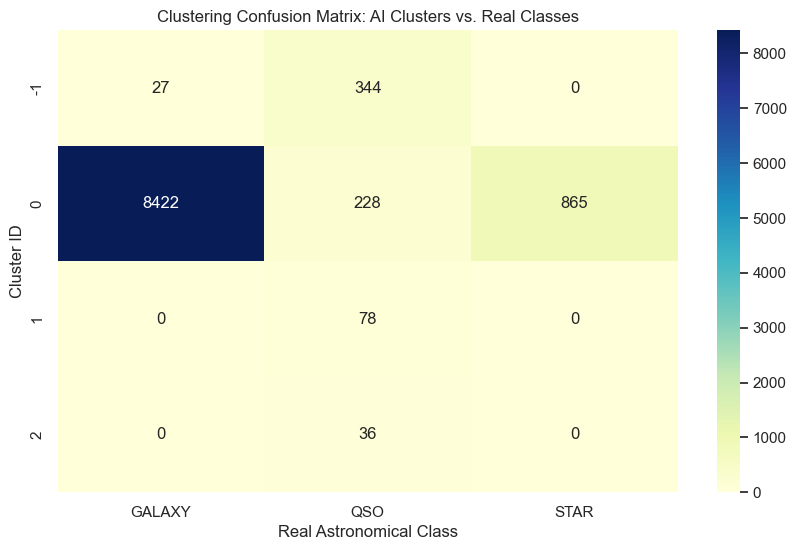

In [ ]:
# Contingency Matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ct = pd.crosstab(df_clustered['cluster'], real_y, 
                 rownames=['Cluster ID'], 
                 colnames=['Real Astronomical Class'])

plt.figure(figsize=(10, 6))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu', cbar=True)
plt.title('Clustering Confusion Matrix: AI Clusters vs. Real Classes')
plt.show()
